In [1]:
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"
import netket as nk
import numpy as np
import netket as nk
import jax
import jax.numpy as jnp
import jax.tree_util as tree
import jax.typing as jt
import matplotlib.pyplot as plt
import optax
from flax import nnx
from flax import linen as nn
from netket.operator import AbstractOperator
from netket.experimental.observable import Renyi2EntanglementEntropy
from tqdm import tqdm
from netket.jax import jacobian
from itertools import product
from typing import Callable, Sequence
from jax.flatten_util import ravel_pytree
from scipy.optimize import minimize

C:\Users\iclis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Definimos el espacio en el que vamos a trabajar
from netket.hilbert import Spin, DiscreteHilbert, TensorHilbert
N = 1
N_ancilla = 1

# Sistema principal: N espines 1/2
# Ancilla: N_ancilla espines 1/2
hi_system = nk.hilbert.Spin(s=1/2, N=N)
# Espacio total = spin ⊗ ancilla
hi_ancilla = nk.hilbert.Spin(s=1/2, N=N_ancilla)
hi_extended = nk.hilbert.Spin(s=1/2, N=N+N_ancilla)

$\mathcal{H_0}=Γ \sum_{i}\sigma_i^{(x)}+V\sum_{i}\sigma_i^{(z)}\sigma_{i+1}^{z} \qquad \mathcal{H_R}=\mathbb{I}_R$

$\mathcal{H}=\mathcal{H_0}\otimes\mathbb{I}_R$

In [3]:
# Importamos las matrices de Pauli y definimos el Hamiltoniano  H = H_0 ⊗ I_R
from netket.operator.spin import sigmax, sigmaz
Gamma = -1.5  
V = -1
H_system=0
H_extended = 0

for i in range(N):
    H_system += Gamma * sigmax(hi_system, i)
    H_system += V * sigmaz(hi_system, i) @ sigmaz(hi_system, (i + 1) % N)

for i in range(N):
    # Estos operadores automáticamente son σ_x^i ⊗ I_R
    H_extended += Gamma * sigmax(hi_extended, i)
    H_extended += V * sigmaz(hi_extended, i) @ sigmaz(hi_extended, (i + 1) % N)

$F_R=\langle H \rangle -TS_2$

Necesitamos una función que calcule $S_2$ y su gradiente. Utilizaremos:

$S_2=-\log(Tr(\rho_A^2))=-\log\left\langle\frac{\psi(r,\eta')\psi(r',\eta)}{\psi(r,\eta)\psi(r',\eta')}\right\rangle$

In [4]:
# Función que emplea el swap trick para calcular la entropía de entrelazamiento
def renyi2_entropy_sampled(vstate, N, subsystem_sites, n_samples, key=0, debug=False):
    """
    Estima la entropía de entrelazamiento de Rényi-2 (S₂) mediante muestreo Monte Carlo
    usando el *swap trick*.

    Calcula:
        S₂ = -log( ⟨SWAP⟩ )

    donde ⟨SWAP⟩ es el valor esperado del operador swap que intercambia el subsistema
    `subsystem_sites` entre dos copias independientes del estado |ψ⟩.

    El valor esperado se estima estocásticamente a partir de muestras generadas con
    `vstate.sample`.

    Args:
        vstate : netket.vqs.MCState
            Estado variacional de NetKet que representa la función de onda |ψ⟩.

        N : int
            Número total de grados de libertad (spins/qubits).
            (Nota: actualmente no se usa explícitamente dentro de la función).

        subsystem_sites : array-like
            Índices de los sitios que definen el subsistema A.
            La entropía se calcula entre A y su complemento.

        n_samples : int
            Número de muestras Monte Carlo usadas para estimar ⟨SWAP⟩.
            Se generan 2 * n_samples configuraciones en total.

        key : int, optional
            Semilla para la permutación aleatoria de las muestras (JAX PRNG key).
            Default: 0.

        debug : bool, optional
            Si True, imprime información detallada sobre:
            - muestras generadas
            - configuraciones intercambiadas
            - valores medios de log |ψ|
            - estimación de ⟨SWAP⟩

    Returns:
       S2 : jax.numpy.DeviceArray
        Estimación Monte Carlo de la entropía de Rényi-2 del subsistema definido
        por `subsystem_sites`.

    """

    # Asegurar que subsystem_sites es un array de enteros
    subsystem_sites = jnp.array(subsystem_sites, dtype=int)

    # Muestras
    all_samples = vstate.sample(n_samples=2 * n_samples, n_discard_per_chain=1000).reshape(-1, vstate.hilbert.size)
    key = jax.random.PRNGKey(key)
    all_samples = jax.random.permutation(key, all_samples, axis=0)
    samples1 = all_samples[:n_samples]
    samples2 = all_samples[n_samples:2*n_samples]
    if debug:
      print(f"Samples1 shape: {samples1.shape}, Samples2 shape: {samples2.shape}")
      # print(f"All samples: " {all_samples})
      print(f"Samples1: {samples1}")
      print(f"Samples2: {samples2}")

    # Calcular el complementario
    all_sites = jnp.arange(samples1.shape[1])
    complement_sites = jnp.setdiff1d(all_sites, subsystem_sites)


    # Intercambio de subsistemas
    swapped1 = jnp.concatenate([samples2[:, subsystem_sites], samples1[:, complement_sites]], axis=1)
    swapped2 = jnp.concatenate([samples1[:, subsystem_sites], samples2[:, complement_sites]], axis=1)
    if debug:
      print(f"Swapped1 shape: {swapped1.shape}, Swapped2 shape: {swapped2.shape}")
      print(f"Swapped1: {swapped1}")
      print(f"Swapped2: {swapped2}")

    # Log amplitudes de las configuraciones originales y permutadas
    log_psi_orig1 = vstate.log_value(samples1)
    log_psi_orig2 = vstate.log_value(samples2)
    log_psi_swap1 = vstate.log_value(swapped1)
    log_psi_swap2 = vstate.log_value(swapped2)
    if debug:
      # print("log|ψ(x)|² medio:", jnp.mean(jnp.abs(log_psi_orig1)), "log|ψ(y)|² medio:", jnp.mean(jnp.abs(log_psi_orig2)))
      print("log|ψ(x)|² medio:", jnp.mean(jnp.abs(log_psi_orig1)).item(),  "log|ψ(y)|² medio:", jnp.mean(jnp.abs(log_psi_orig2)).item())
      print("log|ψ(swapped)|² medio:", jnp.mean(jnp.abs(log_psi_swap1)).item(), "log|ψ(swapped)|² medio:", jnp.mean(jnp.abs(log_psi_swap2)).item())

    # ⟨SWAP⟩ = ⟨ψ(x')ψ(y') / [ψ(x)ψ(y)]⟩
    swap_ratio = jnp.exp((log_psi_swap1 + log_psi_swap2) - (log_psi_orig1 + log_psi_orig2))
    swap_exp = jnp.mean(swap_ratio)
    if debug:
      jax.debug.print("swap ratio = {}", jnp.round(swap_ratio, 4))
      print(f"⟨SWAP⟩ = {swap_exp.item()}")

    # Entropía de Rényi 2
    S2 = -jnp.log(jnp.abs(swap_exp))
    return S2

def renyi2_entropy_exact(vstate, subsystem_sites):
    """
    Calcula la entropía de Rényi-2 de forma exadta usando matriz densidad.
    
    S2 = -ln(Tr(ρ_A^2))
    
    Args:
        vstate: NetKet variational state
        subsystem_sites: lista de sitios del subsistema A
        
    Returns:
        S2: Entropía de Rényi-2
    """
    N = vstate.hilbert.size
    subsystem_sites = np.array(subsystem_sites, dtype=int)
    
    # Obtener vector de estado completo
    psi, basis = vstate_to_vector(vstate)
    
    # Dimensiones
    n_A = len(subsystem_sites)
    n_B = N - n_A
    dim_A = 2**n_A
    dim_B = 2**n_B
    
    # print(f"Sistema total: {N} qubits")
    # print(f"Subsistema A: {n_A} qubits (sitios {subsystem_sites})")
    # print(f"Subsistema B: {n_B} qubits")
    # print(f"dim(A) = {dim_A}, dim(B) = {dim_B}")
    
    # Identificar qubits del complemento
    all_sites = np.arange(N)
    complement_sites = np.setdiff1d(all_sites, subsystem_sites)
    
    # Reorganizar la base para tener (A, B) ordenados
    # Convertir {-1,+1} a {0,1} para indexar
    basis_01 = ((basis + 1) // 2).astype(int)
    
    # Crear índices para reorganizar
    # Queremos: primero los qubits de A, luego los de B
    reordered_sites = np.concatenate([subsystem_sites, complement_sites])
    basis_reordered = basis_01[:, reordered_sites]
    
    # Convertir cada configuración a un índice único
    # Índice = suma de 2^i * bit_i
    powers_A = 2**np.arange(n_A)[::-1]
    powers_B = 2**np.arange(n_B)[::-1]
    
    idx_A = (basis_reordered[:, :n_A] * powers_A).sum(axis=1)
    idx_B = (basis_reordered[:, n_A:] * powers_B).sum(axis=1)
    
    # Construir el vector de estado en forma matricial |ψ⟩ → ψ[i_A, i_B]
    psi_matrix = jnp.zeros((dim_A, dim_B), dtype=complex)
    psi_matrix = psi_matrix.at[idx_A, idx_B].set(psi)
    
    # Matriz densidad del sistema completo: ρ = |ψ⟩⟨ψ|
    # No necesitamos construirla explícitamente para la traza parcial
    
    # Traza parcial sobre B: ρ_A = Tr_B(|ψ⟩⟨ψ|)
    # ρ_A[i,j] = Σ_k ψ[i,k] ψ*[j,k]
    rho_A = psi_matrix @ jnp.conj(psi_matrix.T)
    
    # Verificar que es hermítica y normalizada
    # print(f"\n|ψ|² = {jnp.sum(jnp.abs(psi)**2):.6f} (debe ser 1)")
    # print(f"Tr(ρ_A) = {jnp.trace(rho_A):.6f} (debe ser 1)")
    hermiticity_error = jnp.max(jnp.abs(rho_A - jnp.conj(rho_A.T)))
    # print(f"Error hermiticidad: {hermiticity_error:.2e}")
    
    # Calcular ρ_A^2
    rho_A_squared = rho_A @ rho_A
    
    # Pureza y entropía de Rényi-2
    purity = jnp.trace(rho_A_squared).real
    S2 = -jnp.log(purity)
    
    # print(f"\nTr(ρ_A²) = {purity:.6f} (pureza)")
    # print(f"S2 = -ln(Tr(ρ_A²)) = {S2:.6f}")
    
    # Información adicional: autovalores de ρ_A
    eigenvalues = jnp.linalg.eigvalsh(rho_A)
    eigenvalues = jnp.sort(eigenvalues)[::-1]  # Ordenar descendente
    # print(f"\nAutovalores de ρ_A:")
    # for i, eig in enumerate(eigenvalues):
    #     if eig.real > 1e-10:  # Mostrar solo los significativos
    #         print(f"  λ_{i} = {eig.real:.6f}")
    
    # Entropía de von Neumann (para comparar)
    # S_vN = -Tr(ρ_A ln ρ_A) = -Σ λ_i ln(λ_i)
    eigenvalues_clean = jnp.where(eigenvalues > 1e-10, eigenvalues, 1)  # Evitar log(0)
    S_vN = -jnp.sum(eigenvalues * jnp.log(eigenvalues_clean)).real
    # print(f"\nS_vN (von Neumann) = {S_vN:.6f} (para comparar)")
    
    return S2, rho_A

def vstate_to_vector(vstate):
    """
    Convierte un vstate de NetKet a un vector de estado completo.
    
    Args:
        vstate: NetKet variational state
        
    Returns:
        state_vector: Vector completo normalizado (2^N dimensiones)
        basis_states: Configuraciones correspondientes a cada entrada
    """
    N = vstate.hilbert.size
    
    # Generar todas las configuraciones posibles
    # NetKet usa {-1, +1} para spins
    all_configs = jnp.array(list(product([-1, 1], repeat=N)))
    
    # Obtener amplitudes
    log_psi = vstate.log_value(all_configs)
    psi = jnp.exp(log_psi)
    
    # Normalizar
    norm = jnp.sqrt(jnp.sum(jnp.abs(psi)**2))
    state_vector = psi / norm
    
    return state_vector, all_configs

def renyi2_entropy_and_grad_sampled(vstate, subsystem_sites, n_samples, key=0, debug=False):
    """
    Calcula la entropía de Rényi-2 de un subsistema y su gradiente, este ultimo utilizando
    el gradiente de la log-amplitud de las samples
    
    Args:
        vstate: estado variacional de NetKet
        subsystem_sites: índices del subsistema
        n_samples: número de muestras
        key: semilla aleatoria
        debug: modo depuración
    
    Returns:
        S2: entropía de Rényi-2
        grad_S2: gradiente respecto a parámetros (misma estructura que vstate.parameters)
    """
    subsystem_sites = jnp.array(subsystem_sites, dtype=int)
    
    # ============================================================
    # 1) MUESTREO
    # ============================================================
    all_samples = vstate.sample(n_samples=2 * n_samples, n_discard_per_chain=1000).reshape(-1, vstate.hilbert.size)
    key = jax.random.PRNGKey(key)
    all_samples = jax.random.permutation(key, all_samples, axis=0)
    
    samples1 = all_samples[:n_samples]
    samples2 = all_samples[n_samples:2*n_samples]
    
    if debug:
        print(f"Samples1 shape: {samples1.shape}, Samples2 shape: {samples2.shape}")
    
    # ============================================================
    # 2) CREACIÓN DE CONFIGURACIONES SWAP
    # ============================================================
    all_sites = jnp.arange(samples1.shape[1])
    complement_sites = jnp.setdiff1d(all_sites, subsystem_sites)
    
    swapped1 = jnp.concatenate([samples2[:, subsystem_sites], samples1[:, complement_sites]], axis=1)
    swapped2 = jnp.concatenate([samples1[:, subsystem_sites], samples2[:, complement_sites]], axis=1)
    
    if debug:
        print(f"Swapped1 shape: {swapped1.shape}, Swapped2 shape: {swapped2.shape}")
    
    # ============================================================
    # 3) LOG-AMPLITUDES
    # ============================================================
    log_o1 = vstate.log_value(samples1)
    log_o2 = vstate.log_value(samples2)
    log_s1 = vstate.log_value(swapped1)
    log_s2 = vstate.log_value(swapped2)
    
    if debug:
        print(f"mean log|ψ(orig1)|: {jnp.mean(jnp.abs(log_o1)):.6f}")
        print(f"mean log|ψ(orig2)|: {jnp.mean(jnp.abs(log_o2)):.6f}")
        print(f"mean log|ψ(swap1)|: {jnp.mean(jnp.abs(log_s1)):.6f}")
        print(f"mean log|ψ(swap2)|: {jnp.mean(jnp.abs(log_s2)):.6f}")
    
    # ============================================================
    # 4) RATIO SWAP Y ENTROPÍA S₂
    # ============================================================
    R = jnp.exp((log_s1 + log_s2) - (log_o1 + log_o2))  
    R_mean = jnp.mean(R)
    S2 = -jnp.log(jnp.abs(R_mean))
    
    if debug:
        print(f"⟨SWAP⟩ = {R_mean:.6f}")
        print(f"S₂ = {S2:.6f}")
    
    # ============================================================
    # 5) GRADIENTES (O_θ = ∂_θ log ψ)
    # ============================================================
    O_o1 = jacobian(vstate._apply_fun, vstate.parameters, samples1,
                    model_state=vstate.model_state,
                    mode="real", dense=False)  
    
    O_o2 = jacobian(vstate._apply_fun, vstate.parameters, samples2,
                    model_state=vstate.model_state,
                    mode="real", dense=False)
    
    O_s1 = jacobian(vstate._apply_fun, vstate.parameters, swapped1,
                    model_state=vstate.model_state,
                    mode="real", dense=False)
    
    O_s2 = jacobian(vstate._apply_fun, vstate.parameters, swapped2,
                    model_state=vstate.model_state,
                    mode="real", dense=False)
    
    # ============================================================
    # 6) ΔO = O(x') + O(y') - O(x) - O(y)
    # ============================================================
    DeltaO = jax.tree_util.tree_map(
        lambda s1, s2, o1, o2: s1 + s2 - o1 - o2,
        O_s1, O_s2, O_o1, O_o2
    )
    
    # ============================================================
    # 7) ⟨R * ΔO⟩ (promedio ponderado por R)
    # ============================================================
    def weighted_average(leaf):
        """
        leaf: array de forma (n_samples, *param_shape)
        Calcula ⟨R * leaf⟩ promediando sobre axis=0
        """
        # Expandir R para broadcasting: (n_samples, 1, 1, ...)
        expanded_R = R.reshape(-1, *([1] * (leaf.ndim - 1)))
        return jnp.mean(expanded_R * leaf, axis=0)
    
    numerator = jax.tree_util.tree_map(weighted_average, DeltaO)
    
    # ============================================================
    # 8) ∂θ S₂ = - ⟨R ΔO⟩ / ⟨R⟩
    # ============================================================
    grad_S2 = jax.tree_util.tree_map(lambda x: -x / R_mean, numerator)
    
    if debug:
        # Calcular norma del gradiente para debug
        flat_grad = jax.tree_util.tree_leaves(grad_S2)
        grad_norm = jnp.sqrt(sum(jnp.sum(g**2) for g in flat_grad))
        print(f"|∇S₂| = {grad_norm:.6f}")
    
    return S2, grad_S2

def renyi2_entropy_and_grad_fullsum(vstate, subsystem_sites, debug=False):
    """
    Calcula la entropía de Rényi-2 y su gradiente usando la matriz de densidad reducida.
    Compatible con FullSumState.
    
    Args:
        vstate: estado variacional de NetKet (FullSumState)
        subsystem_sites: índices del subsistema A
        debug: modo depuración
    
    Returns:
        S2: entropía de Rényi-2 = -log(Tr(ρ_A^2))
        grad_S2: gradiente respecto a parámetros
    """
    from netket.jax import jacobian
    
    N = vstate.hilbert.size
    subsystem_sites = np.array(subsystem_sites, dtype=int)
    
    # =======================================
    # 1) OBTENER VECTOR DE ESTADO COMPLETO 
    # =======================================
    psi, basis = vstate_to_vector(vstate)
    
    # Dimensiones
    n_A = len(subsystem_sites)
    n_B = N - n_A
    dim_A = 2**n_A
    dim_B = 2**n_B
    
    if debug:
        print(f"Sistema total: {N} qubits")
        print(f"Subsistema A: {n_A} qubits (sitios {subsystem_sites})")
        print(f"dim(A) = {dim_A}, dim(B) = {dim_B}")
    
    # ============================
    # 2) REORGANIZAR COMO MATRIZ 
    # ============================
    all_sites = np.arange(N)
    complement_sites = np.setdiff1d(all_sites, subsystem_sites)
    
    # Convertir {-1,+1} a {0,1}
    basis_01 = ((basis + 1) // 2).astype(int)
    
    # Reorganizar: primero A, luego B
    reordered_sites = np.concatenate([subsystem_sites, complement_sites])
    basis_reordered = basis_01[:, reordered_sites]
    
    # Convertir a índices
    powers_A = 2**np.arange(n_A)[::-1]
    powers_B = 2**np.arange(n_B)[::-1]
    
    idx_A = (basis_reordered[:, :n_A] * powers_A).sum(axis=1)
    idx_B = (basis_reordered[:, n_A:] * powers_B).sum(axis=1)
    
    # Construir matriz ψ[i_A, i_B]
    psi_matrix = jnp.zeros((dim_A, dim_B), dtype=complex)
    psi_matrix = psi_matrix.at[idx_A, idx_B].set(psi)
    
    # =====================
    # 3) CALCULAR ρ_A Y S₂ 
    # =====================
    rho_A = psi_matrix @ jnp.conj(psi_matrix.T)
    rho_A_squared = rho_A @ rho_A
    purity = jnp.trace(rho_A_squared).real
    S2 = -jnp.log(purity)
    
    if debug:
        print(f"|ψ|² = {jnp.sum(jnp.abs(psi)**2):.6f}")
        print(f"Tr(ρ_A) = {jnp.trace(rho_A).real:.6f}")
        print(f"Tr(ρ_A²) = {purity:.6f}")
        print(f"S₂ = {S2:.6f}")
    
    # ========================
    # 4) CALCULAR GRADIENTE
    # ========================
    # Calcular jacobianos O = ∂log(ψ)/∂θ para todas las configuraciones
    O_all = jacobian(vstate._apply_fun, vstate.parameters, basis,
                     model_state=vstate.model_state, mode="real", dense=False)
    
    # ∂S₂/∂θ = -(1/Tr(ρ_A²)) * ∂Tr(ρ_A²)/∂θ
    # 
    # Tr(ρ_A²) = Σ_{i,j,k} ψ[i,k] ψ*[j,k] ψ[j,ℓ] ψ*[i,ℓ]
    #
    # ∂Tr(ρ_A²)/∂θ = 2 Re[Σ_{i,j,k} (∂ψ[i,k]/∂θ) ψ*[j,k] (ρ_A²)[j,i]]
    
    def compute_grad_for_leaf(O_leaf):
        """Calcula el gradiente para una hoja del árbol de parámetros"""
        param_shape = O_leaf.shape[1:]
        grad_accum = jnp.zeros(param_shape, dtype=jnp.complex128)
        
        n_configs = len(basis)
        
        for config_idx in range(n_configs):
            i_A = idx_A[config_idx]
            i_B = idx_B[config_idx]
            
            # ∂ψ[i_A, i_B]/∂θ = ψ[i_A, i_B] * O[config_idx]
            d_psi_dtheta = psi[config_idx] * O_leaf[config_idx]
            
            # Contribución: Σ_j ψ*[j, i_B] * (ρ_A²)[j, i_A]
            # Equivalente a: (ψ_matrix[:, i_B])† @ (ρ_A²)[:, i_A]
            contribution = jnp.conj(psi_matrix[:, i_B]) @ rho_A_squared[:, i_A]
            
            grad_accum = grad_accum + contribution * O_leaf[config_idx]
        
        return 2.0 * grad_accum.real
    
    grad_trace = jax.tree_util.tree_map(compute_grad_for_leaf, O_all)
    
    # ∂S₂/∂θ = -(1/Tr(ρ_A²)) * ∂Tr(ρ_A²)/∂θ
    grad_S2 = jax.tree_util.tree_map(
        lambda g: -g / purity,
        grad_trace
    )
    
    if debug:
        flat_grad = jax.tree_util.tree_leaves(grad_S2)
        grad_norm = jnp.sqrt(sum(jnp.sum(g**2) for g in flat_grad))
        print(f"|∇S₂| = {grad_norm:.6f}")
    
    return S2, grad_S2

def renyi2_entropy_and_grad_stable(vstate, subsystem_sites, n_samples, key=0, debug=False):
    """
    Calcula la entropía de Rényi-2 de un subsistema y su gradiente de forma similar a "renyi2_entropy_and_grad_sampled"
    pero numéricamente estable (aún no funciona bien del todo)
    
    Usa logsumexp y diferenciación automática para evitar overflow/underflow.
    
    Args:
        vstate: estado variacional de NetKet
        subsystem_sites: índices del subsistema
        n_samples: número de muestras
        key: semilla aleatoria
        debug: modo depuración
    
    Returns:
        S2: entropía de Rényi-2
        grad_S2: gradiente respecto a parámetros (misma estructura que vstate.parameters)
    """
    subsystem_sites = jnp.array(subsystem_sites, dtype=int)
    
    # ============================================================
    # 1) MUESTREO - Dos conjuntos independientes
    # ============================================================
    rng = jax.random.PRNGKey(key)
    rng1, rng2 = jax.random.split(rng)
    
    samples1 = vstate.sample(n_samples=n_samples, n_discard_per_chain=1000).reshape(-1, vstate.hilbert.size)
    samples2 = vstate.sample(n_samples=n_samples, n_discard_per_chain=1000).reshape(-1, vstate.hilbert.size)
    
    # Asegurar mismo tamaño
    M = min(samples1.shape[0], samples2.shape[0])
    samples1 = samples1[:M]
    samples2 = samples2[:M]
    
    if debug:
        print(f"Samples1 shape: {samples1.shape}, Samples2 shape: {samples2.shape}")
    
    # ============================================================
    # 2) PREPARAR SITIOS
    # ============================================================
    all_sites = jnp.arange(samples1.shape[1])
    complement_sites = jnp.setdiff1d(all_sites, subsystem_sites)
    
    # Precomputar configuraciones swapeadas (no dependen de params)
    swapped1 = jnp.concatenate([samples2[:, subsystem_sites], 
                                samples1[:, complement_sites]], axis=1)
    swapped2 = jnp.concatenate([samples1[:, subsystem_sites], 
                                samples2[:, complement_sites]], axis=1)
    
    # ============================================================
    # 3) FUNCIÓN PARA CALCULAR ln P (PURITY) - VERSIÓN EFICIENTE
    # ============================================================
    def log_psi_fn(params, samples):
        """Helper para evaluar log ψ sin crear vstate temporal"""
        return vstate.model.apply(
            {'params': params}, 
            samples,
            mutable=False
        )
    
    def lnP_estimator(params):
        """
        Calcula ln P_A de forma numéricamente estable usando logsumexp.
        
        P_A = ⟨Q⟩ donde Q_k = |ψ(α',β)|² |ψ(α,β')|² / (|ψ(α,β)|² |ψ(α',β')|²)
        
        ln P_A = logsumexp(log Q_k) - ln M
        """
        # Log-amplitudes evaluadas directamente con el modelo
        log_o1 = log_psi_fn(params, samples1)
        log_o2 = log_psi_fn(params, samples2)
        log_s1 = log_psi_fn(params, swapped1)
        log_s2 = log_psi_fn(params, swapped2)
        
        # log Q_k para cada par de muestras k
        log_q_loc = (log_s1 + log_s2) - (log_o1 + log_o2)
        
        # logsumexp automáticamente maneja la estabilidad numérica
        lnP = jax.scipy.special.logsumexp(log_q_loc) - jnp.log(M)
        
        # Tomamos la parte real para asegurar que sea un número real
        return lnP.real
    
    # ============================================================
    # 4) CALCULAR S2 Y SU GRADIENTE
    # ============================================================
    # Primero calculamos S2
    lnP = lnP_estimator(vstate.parameters)
    S2 = -lnP  # S2 = -ln(P)
    
    # Gradiente usando diferenciación automática de JAX
    # JAX automáticamente calcula los pesos softmax al diferenciar logsumexp
    grad_lnP = jax.grad(lnP_estimator)(vstate.parameters)
    
    # Convertir gradiente de ln P a gradiente de S2
    # ∂S2/∂θ = -∂(ln P)/∂θ
    grad_S2 = jax.tree_util.tree_map(lambda g: -g, grad_lnP)
    
    # ============================================================
    # 5) DEBUG INFO
    # ============================================================
    if debug:
        # Calcular algunas métricas para verificación
        log_o1 = vstate.log_value(samples1)
        log_o2 = vstate.log_value(samples2)
        log_s1 = vstate.log_value(swapped1)
        log_s2 = vstate.log_value(swapped2)
        
        print(f"mean log|ψ(orig1)|: {jnp.mean(jnp.abs(log_o1)):.6f}")
        print(f"mean log|ψ(orig2)|: {jnp.mean(jnp.abs(log_o2)):.6f}")
        print(f"mean log|ψ(swap1)|: {jnp.mean(jnp.abs(log_s1)):.6f}")
        print(f"mean log|ψ(swap2)|: {jnp.mean(jnp.abs(log_s2)):.6f}")
        
        log_q_loc = (log_s1 + log_s2) - (log_o1 + log_o2)
        print(f"mean log Q: {jnp.mean(log_q_loc):.6f}")
        print(f"std log Q: {jnp.std(log_q_loc):.6f}")
        print(f"ln P = {lnP:.6f}")
        print(f"S₂ = {S2:.6f}")
        
        # Calcular norma del gradiente
        flat_grad = jax.tree_util.tree_leaves(grad_S2)
        grad_norm = jnp.sqrt(sum(jnp.sum(g**2) for g in flat_grad))
        print(f"|∇S₂| = {grad_norm:.6f}")
    
    return S2, grad_S2

def renyi2_grad_only_stable(vstate, subsystem_sites, n_samples, key=0, debug=False):
    """
    Calcula SOLO el gradiente de S2.
    """
    subsystem_sites = jnp.array(subsystem_sites, dtype=int)
    N = vstate.hilbert.size
    
    # Draw two independent replica batches
    samples1 = vstate.sample(n_samples=n_samples, n_discard_per_chain=1000).reshape(-1, N)
    samples2 = vstate.sample(n_samples=n_samples, n_discard_per_chain=1000).reshape(-1, N)
    
    # M = min(samples1.shape[0], samples2.shape[0])
    # samples1 = samples1[:M]
    # samples2 = samples2[:M]
    
    def lnP_estimator(params, sigma1, sigma2):
        # Split each replica into A and B
        alpha = sigma1[:, subsystem_sites]
        alpha_p = sigma2[:, subsystem_sites]
        
        all_sites = jnp.arange(N)
        complement_sites = jnp.setdiff1d(all_sites, subsystem_sites)
        beta = sigma1[:, complement_sites]
        beta_p = sigma2[:, complement_sites]
        
        # Swapped configurations
        sigma_a_p_b = jnp.concatenate([alpha_p, beta], axis=-1)
        sigma_a_b_p = jnp.concatenate([alpha, beta_p], axis=-1)
        
        def logpsi_batch(p, σ):
            return vstate.model.apply({"params": p}, σ)
        
        logpsi_ab = logpsi_batch(params, sigma1)
        logpsi_a_p_b_p = logpsi_batch(params, sigma2)
        logpsi_a_p_b = logpsi_batch(params, sigma_a_p_b)
        logpsi_a_b_p = logpsi_batch(params, sigma_a_b_p)
        
        # Factor 2.0 para log|ψ|²
        log_q_loc = 2.0 * (
            (logpsi_a_p_b.real + logpsi_a_b_p.real) - 
            (logpsi_ab.real + logpsi_a_p_b_p.real)
        )
        
        lnP = jax.scipy.special.logsumexp(log_q_loc) - jnp.log(log_q_loc.shape[0])
        return lnP
    
    # Gradient of ln P (no S2 computed)
    grad_lnP = jax.grad(lnP_estimator)(vstate.parameters, samples1, samples2)
    
    # Convert to gradient of S2
    grad_S2 = jax.tree_util.tree_map(lambda g: -g, grad_lnP)
    
    if debug:
        grad_dense, _ = ravel_pytree(grad_S2)
        grad_norm = jnp.linalg.norm(grad_dense)
        print(f"|∇S₂| = {grad_norm:.6f}")
    
    return grad_S2

# Jax para calcular el gradiente de la entropía
def renyi2_value_and_grad(vstate, N, subsystem_sites, n_samples=1000, key=0, debug=False):
    '''
    Calcula el gradiente de la entropía mediante diferenciación automática (JAX), 
    pasándole la entropía calculada mediante el swap trick
    en función de los parámetros variacionales del estado |ψ⟩,
    '''
    def S2_func(params):
        vstate_tmp = nk.vqs.MCState(vstate.sampler, vstate.model,
                                  n_samples=vstate.n_samples)
        vstate_tmp.parameters = params
        S2 = renyi2_entropy_sampled(vstate_tmp, N, subsystem_sites, n_samples, key, debug)
        return S2

    S2_val, S2_grad = jax.value_and_grad(S2_func)(vstate.parameters)
    if debug:
        grad_norm = jnp.linalg.norm(nk.jax.jax.flatten_util.ravel_pytree(S2_grad)[0])
        print(f"S₂={S2_val}, ∇S₂={grad_norm}")

    return S2_val, S2_grad

def renyi2_value_and_grad2(vstate, hilbert, partition, isFullSum=False):
    '''
    Calcula el gradiente de la entropía mediante diferenciación automática (JAX), 
    pasándole la entropía calculada la implementación de NetKet
    en función de los parámetros variacionales del estado |ψ⟩,
    '''

    S2_obs = nk.experimental.observable.Renyi2EntanglementEntropy(
        hilbert, partition=partition
    )

    def S2_func(params):
        if isFullSum:
            vstate_tmp = nk.vqs.FullSumState(hi_extended, vstate.model)
        else:
            vstate_tmp = nk.vqs.MCState(sampler=vstate.sampler,model=vstate.model,n_samples=vstate.n_samples,)
        vstate_tmp.parameters = params
        return vstate_tmp.expect(S2_obs).mean.real

    S2_val, S2_grad = jax.value_and_grad(S2_func)(vstate.parameters)
    return S2_val, S2_grad


In [5]:
#MultiLayerPerceptron, model con simetría Z2, 
REAL_DTYPE = jnp.asarray(1.0).dtype
class MultiLayerPerceptron(nn.Module):
    """Flax module for a Multi-layer perceptron architecture with normalization.

    Args:
        layer_widths: Sequence of integers that define both the number of layers
            and their widths.
        activation_funcion: The activation function that will be applied after
            each dense layer.
        kernel_init: Function to initialize the trainable parameters.

    Returns:
        A jax array with the output of the net.
    """

    layer_widths: Sequence[int]
    activation_function: Callable = nn.swish
    kernel_init: Callable = nn.initializers.lecun_normal()

    @nn.compact
    def __call__(self, x) -> jt.ArrayLike:
        for w in self.layer_widths:
            # We cannot use LayerNorm when the output has size 1, since
            # that would destroy the data.
            if w == 1:
                normalizer = lambda x: x
            else:
                normalizer = nn.LayerNorm(param_dtype=REAL_DTYPE)
            x = self.activation_function(
                normalizer(
                    nn.Dense(
                        w,
                        kernel_init=self.kernel_init,
                        param_dtype=REAL_DTYPE,
                    )(x)
                )
            )
        return x.squeeze(axis=-1)
    
class RBM_Z2(nn.Module):

    alpha: int = 1
    trivial_Z2: bool = False  # True → simetría (ψ(x)=ψ(-x)), False → antisimetría (ψ(x)=-ψ(-x))

    @nn.compact
    def __call__(self, x):
        # Definimos la RBM
        # worker = nk.models.RBM(alpha=self.alpha, param_dtype=float) 
        worker = MultiLayerPerceptron(layer_widths=[8,16,8,1])
        worker = nk.models.ARNNDense(
            hilbert= nk.hilbert.Spin(s=1/2, N=N+N_ancilla),
            layers=1,           
            features=16,        
            activation=jax.nn.gelu,
            kernel_init=nn.initializers.variance_scaling(
                scale=0.05,  
                mode='fan_in',
                distribution='truncated_normal'
            ),
            bias_init=nn.initializers.constant(0.1)
        )

        # Calculamos la log-amplitud para x y -x
        output_x = jnp.atleast_1d(worker(x))
        output_inv_x = jnp.atleast_1d(worker(-x))

        # Apilamos las dos
        z2_stack = jnp.stack([output_x, output_inv_x], axis=0)

        # Combinamos según el tipo de simetría
        if self.trivial_Z2:
            # Invariante (simétrica)
            res = jax.nn.logsumexp(z2_stack, axis=0)
        else:
            # Antisimétrica (cambia de signo)
            b = jnp.array([1.0, -1.0])[:, None]   #b es el coeficiente que precede a la exponencial. Por defecto = 1.0
            res = jax.nn.logsumexp(z2_stack, b=b, axis=0)

        return res
        # return nk.nn.log_cosh(res)

Step 0: S₂(SWAP)=0.000026, S₂(NK)=0.000026, S₂(ρₛ)=0.000026, |∇S₂| = 0.02030638
Step 20: S₂(SWAP)=0.000062, S₂(NK)=0.000062, S₂(ρₛ)=0.000062, |∇S₂| = 0.03141024
Step 40: S₂(SWAP)=0.000209, S₂(NK)=0.000209, S₂(ρₛ)=0.000209, |∇S₂| = 0.05786898
Step 60: S₂(SWAP)=0.000720, S₂(NK)=0.000720, S₂(ρₛ)=0.000720, |∇S₂| = 0.10729920
Step 80: S₂(SWAP)=0.002474, S₂(NK)=0.002474, S₂(ρₛ)=0.002474, |∇S₂| = 0.19870471
Step 100: S₂(SWAP)=0.008449, S₂(NK)=0.008449, S₂(ρₛ)=0.008449, |∇S₂| = 0.36611616
Step 120: S₂(SWAP)=0.028290, S₂(NK)=0.028290, S₂(ρₛ)=0.028290, |∇S₂| = 0.66311122
Step 140: S₂(SWAP)=0.088600, S₂(NK)=0.088600, S₂(ρₛ)=0.088600, |∇S₂| = 1.13487970
Step 160: S₂(SWAP)=0.204664, S₂(NK)=0.204664, S₂(ρₛ)=0.204664, |∇S₂| = 1.59646890
Step 180: S₂(SWAP)=0.336859, S₂(NK)=0.336859, S₂(ρₛ)=0.336859, |∇S₂| = 1.81477744
Step 200: S₂(SWAP)=0.453368, S₂(NK)=0.453368, S₂(ρₛ)=0.453368, |∇S₂| = 1.79006609
Step 220: S₂(SWAP)=0.541191, S₂(NK)=0.541191, S₂(ρₛ)=0.541191, |∇S₂| = 1.60354528
Step 240: S₂(SWAP)=0.6

<function matplotlib.pyplot.show(close=None, block=None)>

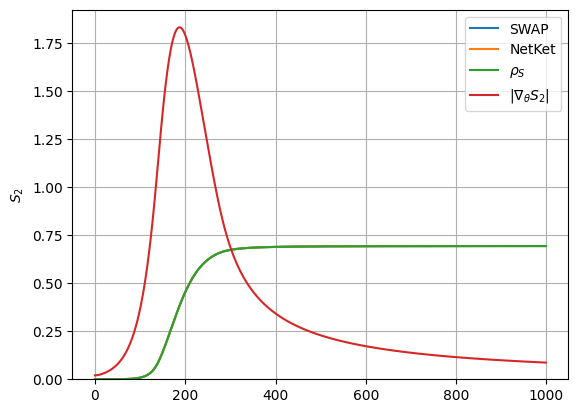

In [6]:
#Comprobar que la derivada del gradiente funciona
#Se busca el estado que maximiza S₂, en nuestro caso max(S₂)=ln(N+N_ancilla)

partition = list(range(N))  
sampler = nk.sampler.ExactSampler(hilbert=hi_extended)
model = RBM_Z2(alpha=1, trivial_Z2=True)
# vstate = nk.vqs.MCState(sampler, model, n_samples=5000)
vstate = nk.vqs.FullSumState(hi_extended, model)
vstate.init_parameters
# lr = optax.warmup_cosine_decay_schedule(init_value=0.5, peak_value=1.5, warmup_steps=300, decay_steps=1000, end_value=0.1)
lr = 0.001
optimizer = optax.chain(optax.clip_by_global_norm(1.0),optax.sgd(learning_rate=lr,momentum=0.9))
# optimizer = optax.chain(optax.clip_by_global_norm(1.0),optax.adam(learning_rate=lr,b1=0.9))
# optimizer = optax.chain(optax.clip_by_global_norm(1.0),optax.adam(learning_rate=lr, b1=0.9, b2=0.99))

opt_state = optimizer.init(vstate.parameters)

S2_history_swap = []
S2_history_nk = []
S2_history_trace = []
S2_grad_history= []

S2_obs = nk.experimental.observable.Renyi2EntanglementEntropy(hi_extended, partition=partition)

for step in range(1000):
    S2_nk = vstate.expect(S2_obs).mean.real*np.log(2)
    # S2, S2_grad_2 = renyi2_entropy_and_grad_sampled(vstate, partition, 5000)
    S2, S2_grad_2 = renyi2_entropy_and_grad_fullsum(vstate, partition)
    S2_trace = renyi2_entropy_exact(vstate, partition)[0]
    S2_grad = jnp.linalg.norm(jax.flatten_util.ravel_pytree(S2_grad_2)[0])
    
    S_grad = jax.tree_util.tree_map(
        lambda grad_S2:  - grad_S2,
        S2_grad_2
    )
    
    updates, opt_state = optimizer.update(S_grad, opt_state, vstate.parameters)
    vstate.parameters = optax.apply_updates(vstate.parameters, updates)

    S2_history_swap.append(S2)
    S2_history_nk.append(S2_nk)
    S2_history_trace.append(S2_trace)
    S2_grad_history.append(S2_grad)
    a = vstate.expect_and_grad(H_extended)
    
    if step % 20 == 0:
        grad_norm = jnp.linalg.norm(jax.flatten_util.ravel_pytree(S_grad)[0])
        print(f"Step {step}: S₂(SWAP)={S2:.6f}, S₂(NK)={S2_nk:.6f}, S₂(ρₛ)={S2_trace:.6f}, |∇S₂| = {S2_grad:.8f}")

plt.plot(S2_history_swap, label="SWAP")
plt.plot(S2_history_nk, label="NetKet")
plt.plot(S2_history_trace, label=r"$\rho_S$")
plt.plot(S2_grad_history, label=r"$|\nabla_\theta S_2$|")
plt.ylabel(r"$S_2$")
plt.ylim(0,)
plt.grid()
plt.legend()
plt.show

Número total de parámetros escalares: 12
Generando landscape 2D...
  Progreso: 0/100
  Progreso: 5/100
  Progreso: 10/100
  Progreso: 15/100
  Progreso: 20/100
  Progreso: 25/100
  Progreso: 30/100
  Progreso: 35/100
  Progreso: 40/100
  Progreso: 45/100
  Progreso: 50/100
  Progreso: 55/100
  Progreso: 60/100
  Progreso: 65/100
  Progreso: 70/100
  Progreso: 75/100
  Progreso: 80/100
  Progreso: 85/100
  Progreso: 90/100
  Progreso: 95/100


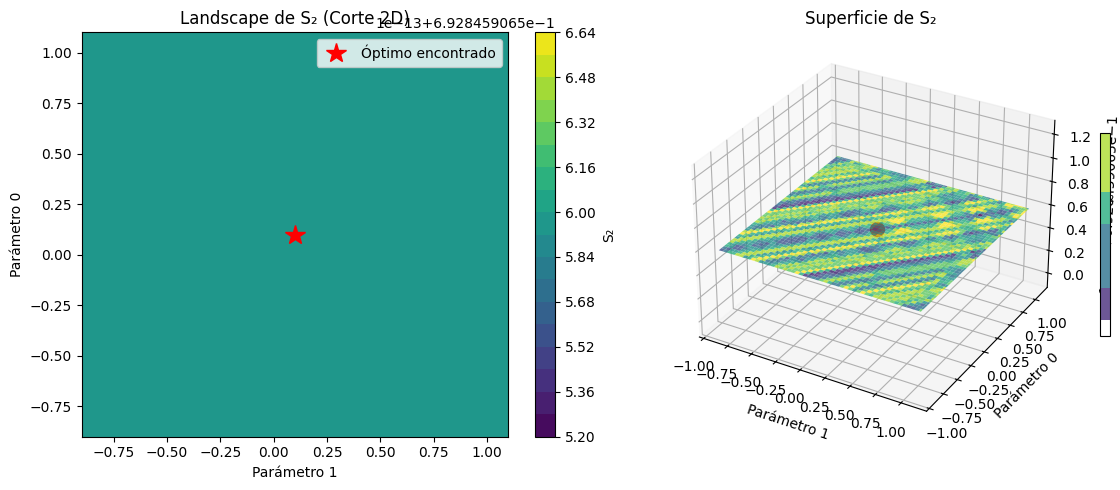


Generando cortes 1D...
  Completado parámetro 0/4
  Completado parámetro 1/4
  Completado parámetro 2/4
  Completado parámetro 3/4


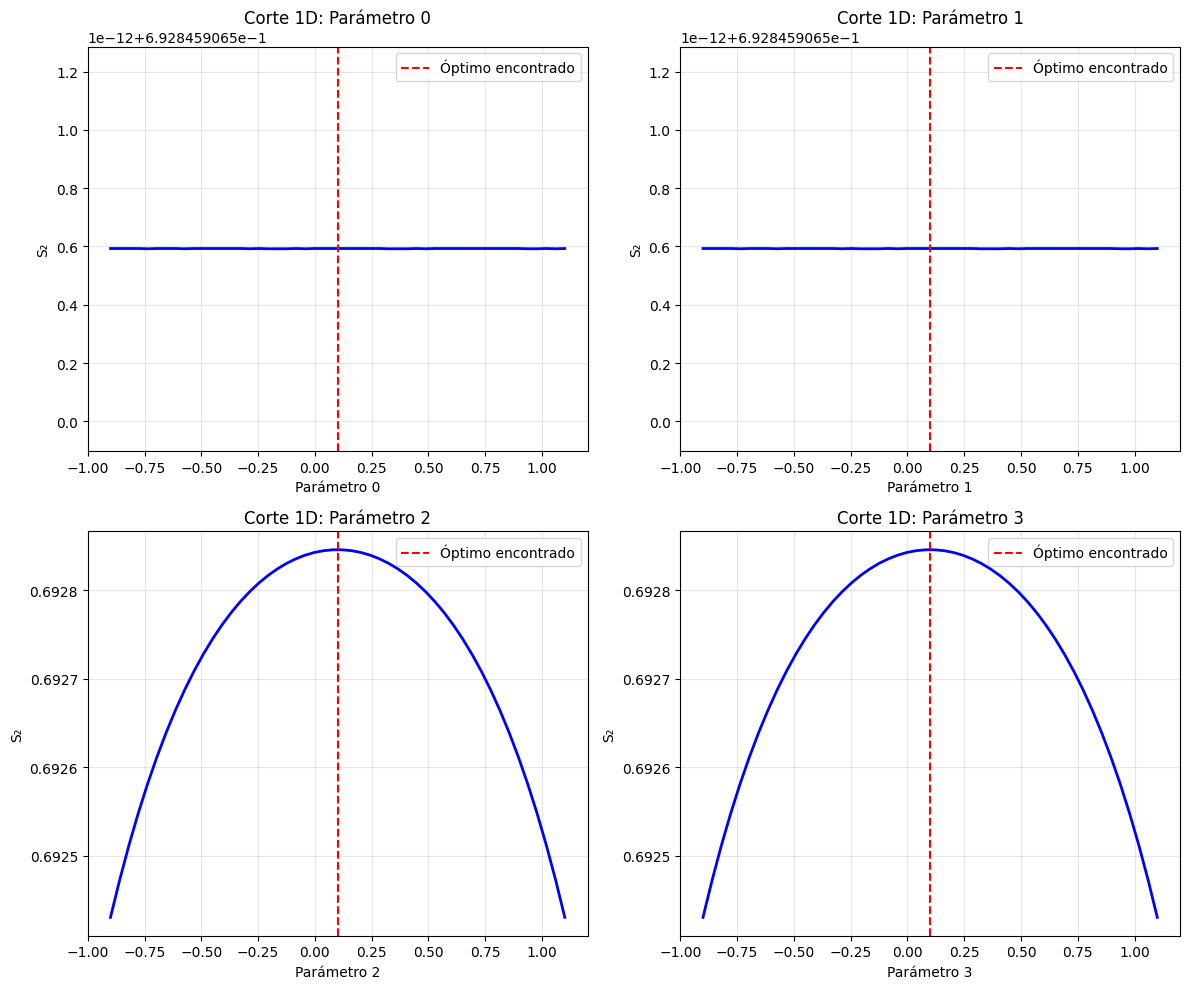

In [7]:
def visualize_s2_landscape(vstate, partition, optimal_params, n_samples=10000):
    """
    Visualiza el landscape de S₂ alrededor de los parámetros óptimos.
    
    Args:
        vstate: Estado variacional
        partition: Partición para calcular entrelazamiento
        optimal_params: Parámetros óptimos encontrados
        n_samples: Número de muestras para calcular S₂
    """
    
    # Aplanar parámetros completamente (incluyendo arrays internos)
    flat_params, tree_def = jax.tree_util.tree_flatten(optimal_params)
    
    # Aplanar completamente todos los arrays a escalares individuales
    all_scalars = []
    param_shapes = []
    param_indices = []  # (array_idx, element_idx)
    
    for i, param in enumerate(flat_params):
        if isinstance(param, (jnp.ndarray, np.ndarray)):
            param_flat = param.flatten()
            for j, scalar in enumerate(param_flat):
                all_scalars.append(float(scalar))
                param_shapes.append(param.shape)
                param_indices.append((i, j))
        else:
            all_scalars.append(float(param))
            param_shapes.append(())
            param_indices.append((i, -1))
    
    n_params = len(all_scalars)
    print(f"Número total de parámetros escalares: {n_params}")
    
    # Seleccionar dos parámetros escalares para explorar
    param_idx_1 = 0
    param_idx_2 = min(1, n_params - 1)
    
    # Definir rangos de exploración 
    param_1_opt = all_scalars[param_idx_1]
    param_2_opt = all_scalars[param_idx_2]
    
    range_factor = 10
    range_abs = max(abs(param_1_opt), 0.1)  # Evitar rangos de cero
    param_1_range = np.linspace(
        param_1_opt - range_factor * range_abs,
        param_1_opt + range_factor * range_abs,
        100
    )
    range_abs = max(abs(param_2_opt), 0.1)
    param_2_range = np.linspace(
        param_2_opt - range_factor * range_abs,
        param_2_opt + range_factor * range_abs,
        100
    )
    
    # ========== CORTE 2D ==========
    print("Generando landscape 2D...")
    S2_landscape = np.zeros((len(param_1_range), len(param_2_range)))
    
    for i, p1 in enumerate(param_1_range):
        for j, p2 in enumerate(param_2_range):
            # Crear nueva configuración de parámetros
            new_scalars = all_scalars.copy()
            new_scalars[param_idx_1] = p1
            new_scalars[param_idx_2] = p2
            
            # Reconstruir estructura de parámetros
            new_flat_params = []
            scalar_idx = 0
            for orig_param in flat_params:
                if isinstance(orig_param, (jnp.ndarray, np.ndarray)):
                    size = orig_param.size
                    new_array = jnp.array(new_scalars[scalar_idx:scalar_idx+size]).reshape(orig_param.shape)
                    new_flat_params.append(new_array)
                    scalar_idx += size
                else:
                    new_flat_params.append(new_scalars[scalar_idx])
                    scalar_idx += 1
            
            new_params = jax.tree_util.tree_unflatten(tree_def, new_flat_params)
            vstate.parameters = new_params
            
            # Calcular S₂
            # S2 = renyi2_entropy_sampled(vstate, N, partition, n_samples)
            S2 = renyi2_entropy_exact(vstate, partition)[0]
            S2_landscape[i, j] = S2
        
        if i % 5 == 0:
            print(f"  Progreso: {i}/{len(param_1_range)}")
    
    # Visualizar corte 2D
    fig = plt.figure(figsize=(12, 5))
    
    # Subplot 1: Mapa de calor
    ax1 = fig.add_subplot(121)
    im = ax1.contourf(param_2_range, param_1_range, S2_landscape, 
                      levels=20, cmap='viridis')
    ax1.plot(param_2_opt, param_1_opt, 'r*', markersize=15, 
             label='Óptimo encontrado')
    ax1.set_xlabel(f'Parámetro {param_idx_2}')
    ax1.set_ylabel(f'Parámetro {param_idx_1}')
    ax1.set_title('Landscape de S₂ (Corte 2D)')
    ax1.legend()
    plt.colorbar(im, ax=ax1, label='S₂')
    
    # Subplot 2: Superficie 3D
    ax2 = fig.add_subplot(122, projection='3d')
    P1, P2 = np.meshgrid(param_2_range, param_1_range)
    surf = ax2.plot_surface(P2, P1, S2_landscape, cmap='viridis', 
                            alpha=0.8, edgecolor='none')
    ax2.scatter([param_2_opt], [param_1_opt], [S2_landscape[len(param_1_range)//2, len(param_2_range)//2]], 
                color='red', s=100, label='Óptimo')
    ax2.set_xlabel(f'Parámetro {param_idx_2}')
    ax2.set_ylabel(f'Parámetro {param_idx_1}')
    ax2.set_zlabel('S₂')
    ax2.set_title('Superficie de S₂')
    plt.colorbar(surf, ax=ax2, shrink=0.5)
    
    plt.tight_layout()
    plt.show()
    
    # ========== CORTES 1D ==========
    print("\nGenerando cortes 1D...")
    
    # Seleccionar algunos parámetros importantes para visualizar
    params_to_plot = min(4, n_params)
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    for idx in range(params_to_plot):
        param_opt = all_scalars[idx]
        range_abs = max(abs(param_opt), 0.1)
        param_range = np.linspace(
            param_opt - range_factor * range_abs,
            param_opt + range_factor * range_abs,
            50
        )
        
        S2_values = []
        for p in param_range:
            new_scalars = all_scalars.copy()
            new_scalars[idx] = p
            
            # Reconstruir estructura de parámetros
            new_flat_params = []
            scalar_idx = 0
            for orig_param in flat_params:
                if isinstance(orig_param, (jnp.ndarray, np.ndarray)):
                    size = orig_param.size
                    new_array = jnp.array(new_scalars[scalar_idx:scalar_idx+size]).reshape(orig_param.shape)
                    new_flat_params.append(new_array)
                    scalar_idx += size
                else:
                    new_flat_params.append(new_scalars[scalar_idx])
                    scalar_idx += 1
            
            new_params = jax.tree_util.tree_unflatten(tree_def, new_flat_params)
            vstate.parameters = new_params
            
            # S2, _ = renyi2_entropy_and_grad_sampled(vstate, partition, n_samples, key=idx*1000+len(S2_values))
            S2 = renyi2_entropy_exact(vstate, partition)[0]
            S2_values.append(S2)
        
        axes[idx].plot(param_range, S2_values, 'b-', linewidth=2)
        axes[idx].axvline(param_opt, color='r', linestyle='--', 
                         label='Óptimo encontrado')
        axes[idx].set_xlabel(f'Parámetro {idx}')
        axes[idx].set_ylabel('S₂')
        axes[idx].set_title(f'Corte 1D: Parámetro {idx}')
        axes[idx].grid(True, alpha=0.3)
        axes[idx].legend()
        
        print(f"  Completado parámetro {idx}/{params_to_plot}")
    
    plt.tight_layout()
    plt.show()
    
    # Restaurar parámetros óptimos
    vstate.parameters = optimal_params

optimal_params = vstate.parameters
visualize_s2_landscape(vstate, partition, optimal_params, n_samples=10000)

In [8]:
state_vector = vstate.to_array()

# Obtener estados individuales con sus amplitudes
basis_states = hi_extended.all_states()
for i, state in enumerate(basis_states):
    amplitude = state_vector[i]
#     print(f"Estado {state}: {amplitude:.3f}")

# Calcular probabilidades
probabilities = jnp.abs(state_vector)**2
for i, state in enumerate(basis_states):
    print(f"P(|{state}⟩) = {probabilities[i]:.3f}")

prob00= sum(probabilities[i] for i, state in enumerate(basis_states) if state[0]==-1 and state[1]==-1)
print(f"\nP(|-1-1⟩): {prob00:.3f}")
prob11= sum(probabilities[i] for i, state in enumerate(basis_states) if state[0]==1 and state[1]==1)
print(f"\nP(|11⟩): {prob11:.3f}")
p01= sum(probabilities[i] for i, state in enumerate(basis_states) if (state[0]==-1 and state[1]==1))
print(f"\nP(|-11⟩): {p01:.3f}")
p10= sum(probabilities[i] for i, state in enumerate(basis_states) if (state[0]==1 and state[1]==-1))
print(f"\nP(|1-1⟩): {p10:.3f}")

P(|[1 1]⟩) = 0.500
P(|[ 1 -1]⟩) = 0.000
P(|[-1  1]⟩) = 0.000
P(|[-1 -1]⟩) = 0.500

P(|-1-1⟩): 0.500

P(|11⟩): 0.500

P(|-11⟩): 0.000

P(|1-1⟩): 0.000


In [9]:
#Minimizar F = <H> - TS₂
def free_energy_minimize (vstate, optimizer, T, partition, Hamiltonian, n_samples, n_steps=1000, verbose=True, isFullSum=False, plot=True):
    opt_state = optimizer.init(vstate.parameters)
    free_energy_history = []
    energy_history = []
    entropy_history = []  
    best_F = np.inf
    best_energy = None
    best_entropy = None

    for step in range(n_steps):
        E, E_grad = vstate.expect_and_grad(Hamiltonian)
        if isFullSum:
            S2, S2_grad = renyi2_entropy_and_grad_fullsum(vstate, partition)
        else:
            S2, S2_grad = renyi2_entropy_and_grad_sampled(vstate, partition, n_samples, key=step)

        F_grad = jax.tree_util.tree_map(
            lambda grad_E, grad_S2: grad_E - T * grad_S2,
            E_grad, S2_grad
        )

        updates, opt_state = optimizer.update(F_grad, opt_state, vstate.parameters)
        vstate.parameters = optax.apply_updates(vstate.parameters, updates)

        F = E.mean.real - T * S2

        free_energy_history.append(F)
        energy_history.append(E.mean.real)
        entropy_history.append(S2)

        if F < best_F:
            best_F = F
            best_energy = E.mean.real
            best_entropy = S2

        if (step % 20)== 0 and verbose :
            grad_norm = jnp.linalg.norm(jax.flatten_util.ravel_pytree(F_grad)[0])
            print(f"Step {step}: E={E.mean.real:.6f}, S₂={S2:.6f}, F={(F):.6f}, |∇F|={grad_norm:.6f}")
    
    if plot:
        fig, ax1 = plt.subplots()

        ax1.plot(free_energy_history, color='tab:blue', label=r"$F$")
        ax1.set_xlabel('Step')
        ax1.set_ylabel(r'$F$')
        ax1.tick_params(axis='y')

        ax2 = ax1.twinx()

        ax2.plot(entropy_history, color='tab:red', label=r"$S_2$")
        ax2.plot(energy_history, color='tab:green', label=r"$\langle H\rangle$")
        ax2.set_ylabel(r'$S_2$, $\langle H\rangle$')
        ax2.tick_params(axis='y')

        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

        plt.tight_layout()
        plt.show()

    return free_energy_history, energy_history, entropy_history, best_F, best_energy, best_entropy

def free_energy_minimize_scipy(vstate,T,partition,Hamiltonian,n_samples,method="L-BFGS-B",options=None,verbose=True,):
    """
    Minimiza F = <H> - T S2 usando scipy
    """

    flat_params0, unravel_fn = ravel_pytree(vstate.parameters)

    free_energy_history = []
    energy_history = []
    entropy_history = []

    def objective(flat_params):
        # Reconstruir parámetros
        vstate.parameters = unravel_fn(flat_params)

        # Energía
        E = vstate.expect(Hamiltonian)

        # Entropía
        # S2 = renyi2_entropy_and_grad_sampled(vstate, partition, n_samples)[0] 
        S2 =  renyi2_entropy_exact(vstate, partition)[0] 

        F = E.mean.real - T * S2

        free_energy_history.append(float(F))
        energy_history.append(float(E.mean.real))
        entropy_history.append(float(S2))

        if verbose:
            print(
                f"F={F:.6f}, E={E.mean.real:.6f}, S₂={S2:.6f}"
            )

        return float(F)

    res = minimize(
        fun=objective,
        x0=np.array(flat_params0, dtype=np.float64),
        method=method,
        options=options or {"maxiter": 200}
    )

    vstate.parameters = unravel_fn(res.x)

    return {
        "result": res,
        "free_energy_history": free_energy_history,
        "energy_history": energy_history,
        "entropy_history": entropy_history,
        "best_F": np.min(free_energy_history),
        "best_energy": energy_history[np.argmin(free_energy_history)],
        "best_entropy": entropy_history[np.argmin(free_energy_history)],
    }


In [10]:
sampler = nk.sampler.ExactSampler(hilbert=hi_extended)
model = RBM_Z2(alpha=1, trivial_Z2=True)
# vstate = nk.vqs.MCState(sampler, model, n_samples=100000)
vstate = nk.vqs.FullSumState(hilbert=hi_extended, model=model)
vstate.init_parameters

result = free_energy_minimize_scipy(
    vstate,
    T=1.7,
    partition=partition,
    Hamiltonian=H_extended,
    n_samples=100000,
    method="BFGS",
    options={"maxiter": 10000},
    verbose=False
)

print(result["result"].success)
print(f"Best F={result["best_F"]:.6f}, E={result["best_energy"]:.6f}, S₂={result["best_entropy"]:.6f}")

True
Best F=-2.555626, E=-1.900000, S₂=0.385662


Step 0: E=-2.422953, S₂=0.051341, F=-2.510233, |∇F|=0.863326
Step 20: E=-2.417275, S₂=0.055121, F=-2.510980, |∇F|=0.894564
Step 40: E=-2.411212, S₂=0.059156, F=-2.511777, |∇F|=0.926734
Step 60: E=-2.404742, S₂=0.063461, F=-2.512625, |∇F|=0.959839
Step 80: E=-2.397843, S₂=0.068049, F=-2.513527, |∇F|=0.993874
Step 100: E=-2.390493, S₂=0.072936, F=-2.514484, |∇F|=1.028832
Step 120: E=-2.382672, S₂=0.078134, F=-2.515500, |∇F|=1.064698
Step 140: E=-2.374356, S₂=0.083658, F=-2.516575, |∇F|=1.101453
Step 160: E=-2.365526, S₂=0.089521, F=-2.517712, |∇F|=1.139068
Step 180: E=-2.356158, S₂=0.095736, F=-2.518910, |∇F|=1.177509
Step 200: E=-2.346235, S₂=0.102316, F=-2.520172, |∇F|=1.216729
Step 220: E=-2.335736, S₂=0.109272, F=-2.521498, |∇F|=1.256676
Step 240: E=-2.324644, S₂=0.116613, F=-2.522887, |∇F|=1.297282
Step 260: E=-2.312944, S₂=0.124349, F=-2.524337, |∇F|=1.338472
Step 280: E=-2.300622, S₂=0.132486, F=-2.525849, |∇F|=1.380155
Step 300: E=-2.287667, S₂=0.141029, F=-2.527417, |∇F|=1.42222

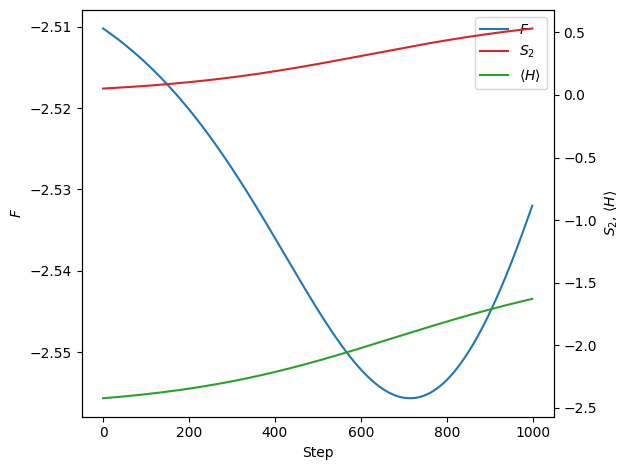

Best solution: S₂=0.385961, E=-1.899492, F=-2.555626


In [18]:
partition = list(range(N))
sampler = nk.sampler.ExactSampler(hilbert=hi_extended)
model = RBM_Z2(alpha=2, trivial_Z2=True)
# vstate = nk.vqs.MCState(sampler, model, n_samples=5000)
vstate = nk.vqs.FullSumState(hi_extended, model)
lr = 0.0005
# lr = optax.warmup_cosine_decay_schedule(init_value=0.4, peak_value=1.5, warmup_steps=300, decay_steps=1000, end_value=0.8)
# lr = optax.linear_onecycle_schedule(transition_steps=1000, peak_value=1.5, pct_start=0.5, pct_final=0.9, div_factor=10, final_div_factor=100)
# lr = optax.cosine_decay_schedule(1, 1000, 0, 1)
# optimizer = optax.chain(optax.clip_by_global_norm(1),optax.sgd(learning_rate=lr,momentum=0.1))
optimizer = optax.sgd(learning_rate=lr,momentum=0.0)
# optimizer = optax.adam(learning_rate=lr)
T = 1.7

f_history,energy_history,s_history,f_best,E_best,S_best = free_energy_minimize(vstate, optimizer, T, partition, H_extended, 5000, isFullSum=True)
print(f"Best solution: S₂={S_best:.6f}, E={E_best:.6f}, F={f_best:.6f}")

T=1.200 -- F=-2.500000, E=-2.500000, S₂=0.000000, True
T=1.242 -- F=-2.500000, E=-2.500000, S₂=0.000000, True
T=1.284 -- F=-2.500000, E=-2.500000, S₂=0.000000, True
T=1.326 -- F=-2.500000, E=-2.500000, S₂=0.000000, True
T=1.368 -- F=-2.500000, E=-2.500000, S₂=0.000000, True
T=1.411 -- F=-2.500000, E=-2.500000, S₂=0.000000, True
T=1.453 -- F=-2.500000, E=-2.500000, S₂=0.000000, True
T=1.495 -- F=-2.500000, E=-2.500000, S₂=0.000000, True
T=1.537 -- F=-2.504988, E=-2.202353, S₂=0.196920, True
T=1.579 -- F=-2.514989, E=-2.085951, S₂=0.271724, True
T=1.621 -- F=-2.527535, E=-2.006391, S₂=0.321485, True
T=1.663 -- F=-2.541894, E=-1.944761, S₂=0.359035, True
T=1.705 -- F=-2.557665, E=-1.894135, S₂=0.389107, True
T=1.747 -- F=-2.574589, E=-1.851105, S₂=0.414042, True
T=1.789 -- F=-2.592479, E=-1.813658, S₂=0.435224, True
T=1.832 -- F=-2.611199, E=-1.780541, S₂=0.453520, True
T=1.874 -- F=-2.630639, E=-1.750863, S₂=0.469543, True
T=1.916 -- F=-2.650713, E=-1.724062, S₂=0.483692, True
T=1.958 --

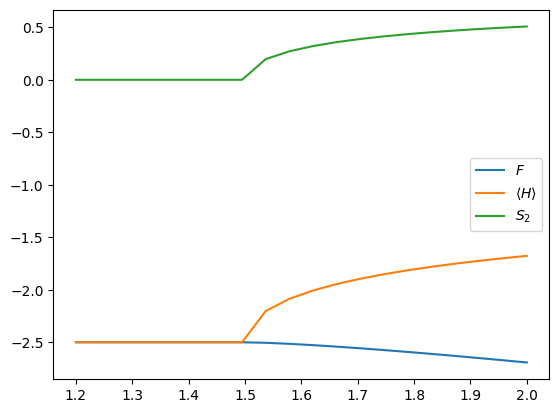

In [14]:
#Minimizar F = <H> - TS₂ en función de T con scipy
T_array = np.linspace(1.2, 2, 20)
model = RBM_Z2(alpha=1, trivial_Z2=True)
# sampler = nk.sampler.ExactSampler(hilbert=hi_extended)

energy_results_scipy = []
entropy_results_scipy = []  
free_energy_results_scipy = []

for T in T_array:
    vstate = nk.vqs.FullSumState(hilbert=hi_extended, model=model) 
    # vstate = nk.vqs.MCState(sampler, model, n_samples=100000)
    result = free_energy_minimize_scipy(
        vstate,
        T=T,
        partition=partition,
        Hamiltonian=H_extended,
        n_samples=100000,
        method="L-BFGS-B",
        options={"maxiter": 10000},
        verbose=False
    )
    energy_results_scipy.append(result["best_energy"])
    entropy_results_scipy.append(result["best_entropy"])
    free_energy_results_scipy.append(result["best_F"])
    print(f"T={T:.3f} -- F={result["best_F"]:.6f}, E={result["best_energy"]:.6f}, S₂={result["best_entropy"]:.6f}, {result["result"].success}")

plt.plot(T_array, free_energy_results_scipy, label=r"$F$")
plt.plot(T_array, energy_results_scipy, label=r"$\langle H\rangle$")
plt.plot(T_array, entropy_results_scipy, label=r"$S_2$")
plt.legend()
plt.show()

Temperaturas:   0%|          | 0/20 [00:00<?, ?it/s]


=== Temperatura T = 1.200 ===


Temperaturas:   5%|▌         | 1/20 [00:18<05:59, 18.91s/it]

  Mejor resultado: E=-2.4907, S₂=0.0127, F=-2.5059

=== Temperatura T = 1.242 ===


Temperaturas:  10%|█         | 2/20 [00:37<05:35, 18.61s/it]

...

  Mejor resultado: E=-2.2618, S₂=0.1893, F=-2.6245

=== Temperatura T = 1.958 ===


Temperaturas:  95%|█████████▌| 19/20 [05:39<00:17, 17.62s/it]

  Mejor resultado: E=-1.9150, S₂=0.3754, F=-2.6500

=== Temperatura T = 2.000 ===


Temperaturas: 100%|██████████| 20/20 [05:55<00:00, 17.78s/it]

  Mejor resultado: E=-1.9380, S₂=0.3662, F=-2.6703


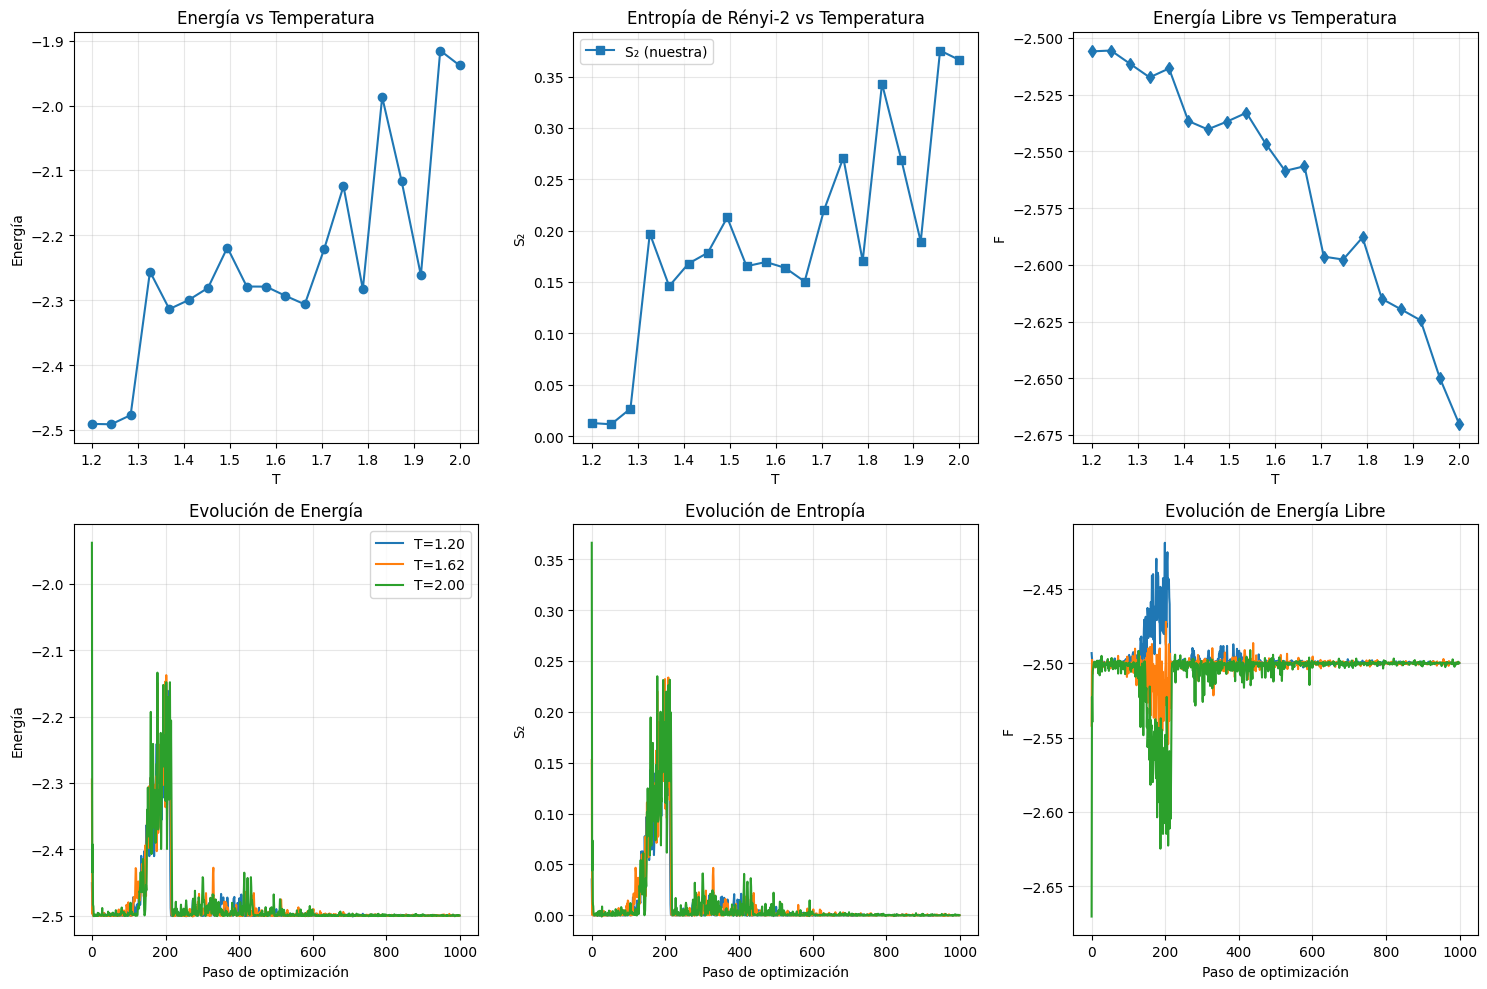


=== RESUMEN DE RESULTADOS ===
Temperatura | Energía | S₂ (SWAP) | Energía Libre
----------------------------------------------------------------------
     1.200 |  -2.4907 |       0.0127 |       -2.5059
     1.242 |  -2.4913 |       0.0114 |       -2.5055
     1.284 |  -2.4772 |       0.0267 |       -2.5115
     1.326 |  -2.2559 |       0.1972 |       -2.5174
     1.368 |  -2.3137 |       0.1459 |       -2.5134
     1.411 |  -2.2997 |       0.1680 |       -2.5366
     1.453 |  -2.2810 |       0.1785 |       -2.5403
     1.495 |  -2.2188 |       0.2128 |       -2.5369
     1.537 |  -2.2789 |       0.1653 |       -2.5330
     1.579 |  -2.2791 |       0.1695 |       -2.5467
     1.621 |  -2.2932 |       0.1637 |       -2.5586
     1.663 |  -2.3064 |       0.1504 |       -2.5566
     1.705 |  -2.2214 |       0.2199 |       -2.5964
     1.747 |  -2.1241 |       0.2710 |       -2.5977
     1.789 |  -2.2830 |       0.1704 |       -2.5879
     1.832 |  -1.9867 |       0.3430 |       -2.6150


True

In [38]:
#Minimizar F = <H> - TS₂ en función de T

sampler = nk.sampler.ExactSampler(hi_extended)
model = RBM_Z2(alpha=1, trivial_Z2=True)

energy_results = []
entropy_results = []  
entropy_netket_results = []  
free_energy_results = []
all_histories = []

for T_idx, T in enumerate(tqdm(T_array, desc="Temperaturas")):
    print(f"\n=== Temperatura T = {T:.3f} ===")
    vstate = nk.vqs.MCState(sampler, model, n_samples=5000)
    lr = optax.warmup_cosine_decay_schedule(init_value=0.5, peak_value=1.5, warmup_steps=300, decay_steps=1000, end_value=0.5)
    # lr = 0.8
    # optimizer = optax.chain(optax.clip_by_global_norm(1.0),optax.adam(learning_rate=lr,b1=0.9,b2=0.999))
    optimizer = optax.chain(optax.clip_by_global_norm(3.0),optax.sgd(learning_rate=lr,momentum=0.3))
    opt_state = optimizer.init(vstate.parameters)
    n_steps = 1000
    
    F_history, energy_history, entropy_history, best_F, best_energy, best_entropy = free_energy_minimize(
        vstate, optimizer, T, partition, H_extended, n_samples=vstate.n_samples, n_steps=n_steps, verbose=False)
    
    energy_results.append(best_energy)
    entropy_results.append(best_entropy)
    free_energy_results.append(best_F)
    
    all_histories.append({
        'T': T,
        'energy': energy_history,
        'entropy': entropy_history,
        'free_energy': F_history
    })
    
    print(f"  Mejor resultado: E={best_energy:.4f}, S₂={best_entropy:.4f}, "
          f"F={best_F:.4f}")

# ========== VISUALIZACIÓN ==========
plt.figure(figsize=(15, 10))

# 1. Resultados finales vs temperatura
plt.subplot(2, 3, 1)
plt.plot(T_array, energy_results, 'o-', label=r'$\langle H \rangle$')
plt.xlabel('T')
plt.ylabel('Energía')
plt.title('Energía vs Temperatura')
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 2)
plt.plot(T_array, entropy_results, 's-', label='S₂ (nuestra)')
plt.xlabel('T')
plt.ylabel('S₂')
plt.title('Entropía de Rényi-2 vs Temperatura')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 3)
plt.plot(T_array, free_energy_results, 'd-', label='F = E - TS₂')
plt.xlabel('T')
plt.ylabel('F')
plt.title('Energía Libre vs Temperatura')
plt.grid(True, alpha=0.3)

# 2. Evolución durante optimización para algunas T seleccionadas
selected_T_indices = [0, len(T_array)//2, -1] 
for idx in selected_T_indices:
    T_val = T_array[idx]
    hist = all_histories[idx]
    
    plt.subplot(2, 3, 4)
    plt.plot(hist['energy'], label=f'T={T_val:.2f}')
    plt.xlabel('Paso de optimización')
    plt.ylabel('Energía')
    plt.title('Evolución de Energía')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 3, 5)
    plt.plot(hist['entropy'], label=f'T={T_val:.2f}')
    plt.xlabel('Paso de optimización')
    plt.ylabel('S₂')
    plt.title('Evolución de Entropía')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 3, 6)
    plt.plot(hist['free_energy'], label=f'T={T_val:.2f}')
    plt.xlabel('Paso de optimización')
    plt.ylabel('F')
    plt.title('Evolución de Energía Libre')
    plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 4).legend()
plt.tight_layout()
plt.savefig("output.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close()
# ========== RESUMEN ==========
print("\n=== RESUMEN DE RESULTADOS ===")
print("Temperatura | Energía | S₂ (SWAP) | Energía Libre")
print("-" * 70)
for i, T in enumerate(T_array):
    print(f"{T:10.3f} | {energy_results[i]:8.4f} | {entropy_results[i]:12.4f} | {free_energy_results[i]:13.4f}")

enviar_grafica_telegram()

Temperaturas:   0%|          | 0/20 [00:00<?, ?it/s]


=== Temperatura T = 0.800 ===
  Step 0: E=-2.4874, S₂=0.0083, F=-2.4941, |∇F|=0.2593
  Step 50: E=-2.5000, S₂=0.0000, F=-2.5000, |∇F|=0.0203
  Step 100: E=-2.5000, S₂=-0.0000, F=-2.5000, |∇F|=0.0225
  Step 150: E=-2.5000, S₂=-0.0000, F=-2.5000, |∇F|=0.0021
  Step 200: E=-2.5000, S₂=0.0000, F=-2.5000, |∇F|=0.0024
  Step 250: E=-2.5004, S₂=0.0003, F=-2.5006, |∇F|=0.0492
  Step 300: E=-2.4994, S₂=0.0004, F=-2.4997, |∇F|=0.0495
  Step 350: E=-2.4996, S₂=-0.0002, F=-2.4995, |∇F|=0.0557
  Step 400: E=-2.5000, S₂=-0.0000, F=-2.4999, |∇F|=0.0291
  Step 450: E=-2.4999, S₂=-0.0000, F=-2.4998, |∇F|=0.0211
  Step 500: E=-2.5001, S₂=0.0000, F=-2.5001, |∇F|=0.0076
  Step 550: E=-2.4999, S₂=-0.0000, F=-2.4999, |∇F|=0.0150
  Step 600: E=-2.4995, S₂=0.0001, F=-2.4996, |∇F|=0.0116
  Step 650: E=-2.5001, S₂=-0.0000, F=-2.5001, |∇F|=0.0167
  Step 700: E=-2.4999, S₂=0.0001, F=-2.5000, |∇F|=0.0036
  Step 750: E=-2.5000, S₂=0.0001, F=-2.5000, |∇F|=0.0049
  Step 800: E=-2.4999, S₂=0.0000, F=-2.5000, |∇F|=0.0

Temperaturas:   5%|▌         | 1/20 [00:25<07:56, 25.06s/it]

  Mejor resultado: E=-2.5006, S₂=0.0006, F=-2.5011

=== Temperatura T = 0.916 ===
  Step 0: E=-2.4151, S₂=0.0538, F=-2.4644, |∇F|=0.6322
  Step 50: E=-2.5000, S₂=0.0000, F=-2.5000, |∇F|=0.0135
  Step 100: E=-2.5000, S₂=-0.0000, F=-2.5000, |∇F|=0.0285
  Step 150: E=-2.4999, S₂=-0.0001, F=-2.4999, |∇F|=0.0398
  Step 200: E=-2.5000, S₂=-0.0000, F=-2.5000, |∇F|=0.0096
  Step 250: E=-2.5000, S₂=0.0001, F=-2.5001, |∇F|=0.0194
  Step 300: E=-2.4997, S₂=0.0000, F=-2.4997, |∇F|=0.0308
  Step 350: E=-2.4999, S₂=-0.0000, F=-2.4999, |∇F|=0.0166
  Step 400: E=-2.5000, S₂=0.0001, F=-2.5001, |∇F|=0.0426
  Step 450: E=-2.4999, S₂=0.0006, F=-2.5005, |∇F|=0.0350
  Step 500: E=-2.5001, S₂=0.0001, F=-2.5001, |∇F|=0.0598
  Step 550: E=-2.5000, S₂=0.0001, F=-2.5001, |∇F|=0.0155
  Step 600: E=-2.4998, S₂=0.0000, F=-2.4999, |∇F|=0.0118
  Step 650: E=-2.5000, S₂=-0.0000, F=-2.5000, |∇F|=0.0118
  Step 700: E=-2.4999, S₂=0.0000, F=-2.4999, |∇F|=0.0256
  Step 750: E=-2.5001, S₂=-0.0000, F=-2.5000, |∇F|=0.0243
  S

Temperaturas:  10%|█         | 2/20 [00:50<07:36, 25.34s/it]

...

  Mejor resultado: E=-2.4438, S₂=0.0386, F=-2.5506

=== Temperatura T = 2.884 ===
  Step 0: E=-2.3771, S₂=0.0850, F=-2.6223, |∇F|=0.7352
  Step 50: E=-2.4998, S₂=0.0001, F=-2.5001, |∇F|=0.0114
  Step 100: E=-2.4995, S₂=0.0002, F=-2.5001, |∇F|=0.0280
  Step 150: E=-2.5000, S₂=0.0000, F=-2.5000, |∇F|=0.0007
  Step 200: E=-2.4999, S₂=0.0001, F=-2.5001, |∇F|=0.0608
  Step 250: E=-2.5003, S₂=0.0001, F=-2.5007, |∇F|=0.0438
  Step 300: E=-2.4913, S₂=0.0022, F=-2.4976, |∇F|=0.2077
  Step 350: E=-2.4995, S₂=0.0001, F=-2.4997, |∇F|=0.1501
  Step 400: E=-2.4970, S₂=0.0010, F=-2.4999, |∇F|=0.0692
  Step 450: E=-2.5004, S₂=0.0001, F=-2.5008, |∇F|=0.0217
  Step 500: E=-2.4979, S₂=0.0002, F=-2.4986, |∇F|=0.1465
  Step 550: E=-2.4998, S₂=0.0001, F=-2.5000, |∇F|=0.0093
  Step 600: E=-2.4992, S₂=0.0006, F=-2.5010, |∇F|=0.0960
  Step 650: E=-2.4996, S₂=0.0003, F=-2.5004, |∇F|=0.0408
  Step 700: E=-2.4997, S₂=0.0003, F=-2.5005, |∇F|=0.0231
  Step 750: E=-2.5000, S₂=0.0000, F=-2.5001, |∇F|=0.0417
  Step 80

Temperaturas:  95%|█████████▌| 19/20 [07:58<00:25, 25.21s/it]

  Mejor resultado: E=-2.3771, S₂=0.0850, F=-2.6223

=== Temperatura T = 3.000 ===
  Step 0: E=-2.3112, S₂=0.1306, F=-2.7030, |∇F|=0.9200
  Step 50: E=-2.4995, S₂=0.0000, F=-2.4996, |∇F|=0.1008
  Step 100: E=-2.4999, S₂=-0.0002, F=-2.4992, |∇F|=0.1466
  Step 150: E=-2.4978, S₂=0.0007, F=-2.4997, |∇F|=0.0885
  Step 200: E=-2.4992, S₂=0.0009, F=-2.5020, |∇F|=0.0919
  Step 250: E=-2.4979, S₂=0.0015, F=-2.5023, |∇F|=0.1115
  Step 300: E=-2.4910, S₂=0.0042, F=-2.5036, |∇F|=0.1916
  Step 350: E=-2.4942, S₂=0.0031, F=-2.5036, |∇F|=0.2990
  Step 400: E=-2.4985, S₂=0.0012, F=-2.5022, |∇F|=0.0722
  Step 450: E=-2.4996, S₂=0.0002, F=-2.5002, |∇F|=0.0233
  Step 500: E=-2.4995, S₂=0.0008, F=-2.5019, |∇F|=0.0709
  Step 550: E=-2.4999, S₂=0.0000, F=-2.5000, |∇F|=0.0264
  Step 600: E=-2.4997, S₂=0.0005, F=-2.5012, |∇F|=0.0544
  Step 650: E=-2.4981, S₂=0.0019, F=-2.5040, |∇F|=0.0748
  Step 700: E=-2.4994, S₂=0.0002, F=-2.5000, |∇F|=0.0730
  Step 750: E=-2.5001, S₂=-0.0000, F=-2.4999, |∇F|=0.0599
  Step 

Temperaturas: 100%|██████████| 20/20 [08:24<00:00, 25.23s/it]

  Mejor resultado: E=-2.3112, S₂=0.1306, F=-2.7030


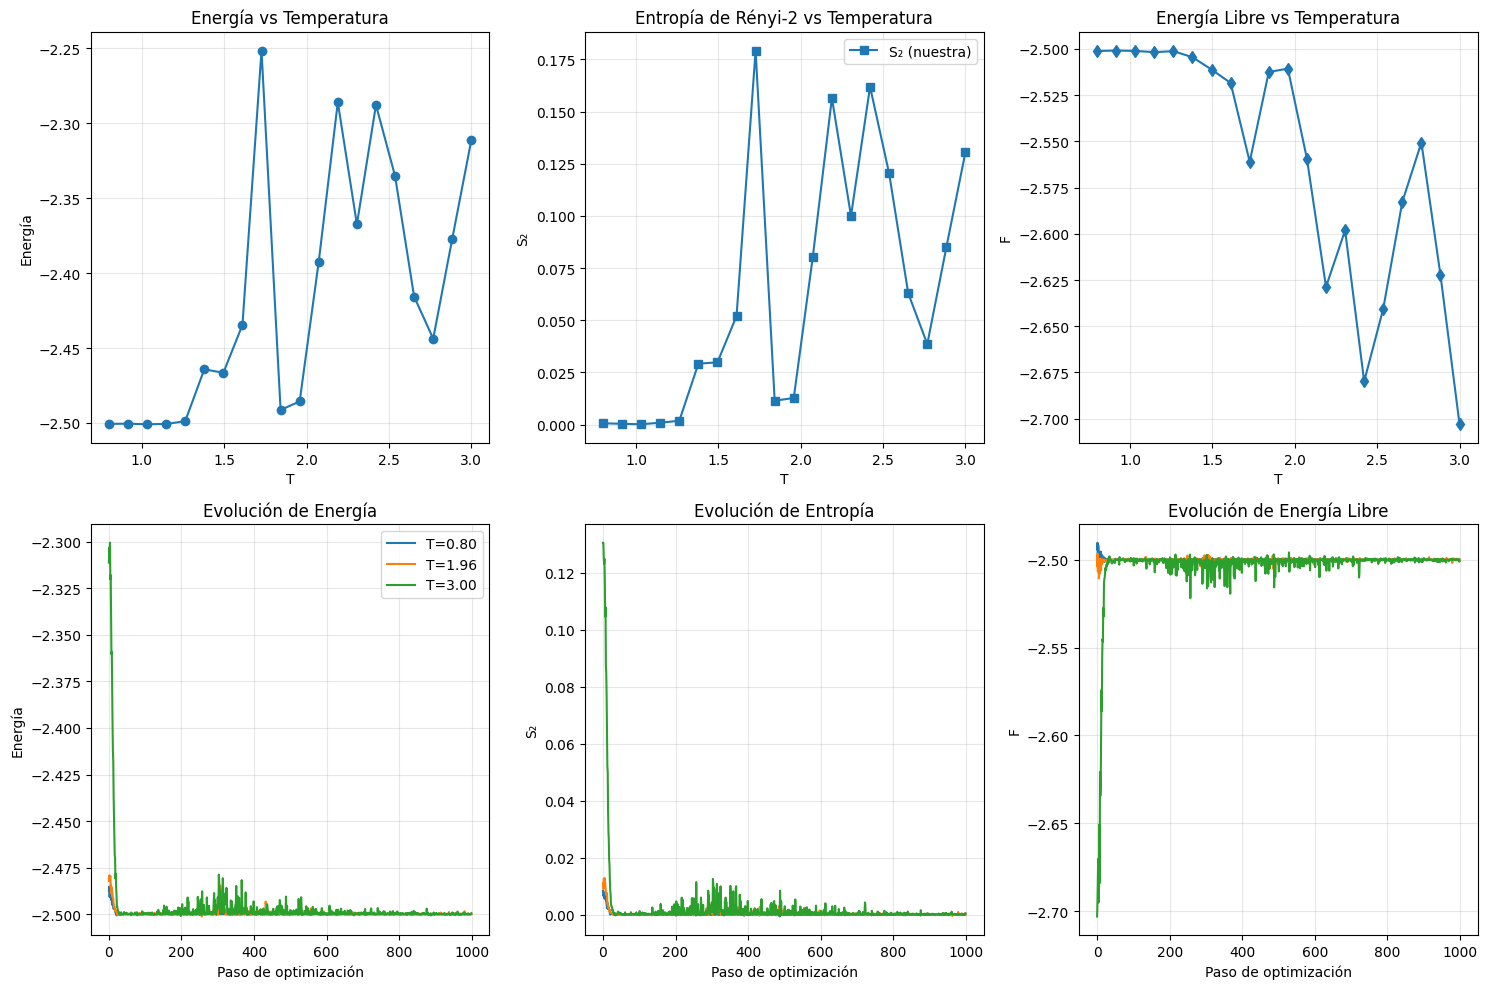


=== RESUMEN DE RESULTADOS ===
Temperatura | Energía | S₂ (SWAP) | Energía Libre
----------------------------------------------------------------------
     0.800 |  -2.5006 |       0.0006 |       -2.5011
     0.916 |  -2.5005 |       0.0004 |       -2.5009
     1.032 |  -2.5009 |       0.0002 |       -2.5011
     1.147 |  -2.5007 |       0.0009 |       -2.5017
     1.263 |  -2.4989 |       0.0019 |       -2.5012
     1.379 |  -2.4642 |       0.0292 |       -2.5045
     1.495 |  -2.4665 |       0.0299 |       -2.5111
     1.611 |  -2.4346 |       0.0520 |       -2.5184
     1.726 |  -2.2515 |       0.1793 |       -2.5610
     1.842 |  -2.4913 |       0.0115 |       -2.5125
     1.958 |  -2.4856 |       0.0128 |       -2.5106
     2.074 |  -2.3924 |       0.0805 |       -2.5594
     2.189 |  -2.2860 |       0.1565 |       -2.6287
     2.305 |  -2.3675 |       0.1000 |       -2.5981
     2.421 |  -2.2879 |       0.1619 |       -2.6799
     2.537 |  -2.3352 |       0.1204 |       -2.6405


True

In [47]:
# Minimizar F = <H> - T S₂ usando SR +SGD

sampler = nk.sampler.ExactSampler(hi_extended)
model = RBM_Z2(alpha=1, trivial_Z2=True)

T_array = np.linspace(0.8, 3, 20)

energy_results = []
entropy_results = []
free_energy_results = []
all_histories = []

n_steps = 1000

for T_idx, T in enumerate(tqdm(T_array, desc="Temperaturas")):
    print(f"\n=== Temperatura T = {T:.3f} ===")

    vstate = nk.vqs.MCState(
        sampler,
        model,
        n_samples=8000,
    )

    # --- Learning rate schedule ---
    lr_schedule = optax.warmup_cosine_decay_schedule(init_value=0.0,peak_value=0.3,warmup_steps=250,decay_steps=n_steps,end_value=0.1,)
    # lr_schedule = optax.cosine_decay_schedule(init_value=0.15,decay_steps=n_steps,alpha=0.5)

    optimizer = nk.optimizer.Sgd(learning_rate=lr_schedule)

    # --- Stochastic Reconfiguration ---
    sr = nk.optimizer.SR(
        diag_shift=optax.linear_schedule(1e-2, 1e-4, n_steps)
    )

    energy_history = []
    entropy_history = []
    F_history = []

    best_F = np.inf
    best_energy = None
    best_entropy = None

    for step in range(n_steps):
        # ---- Energy ----
        E, E_grad = vstate.expect_and_grad(H_extended)

        # ---- Entropy ----
        S2_val, S2_grad = renyi2_entropy_and_grad_sampled(
            vstate,
            subsystem_sites=partition,
            n_samples=8000,
            key=step,
        )

        # ---- Free energy gradient ----
        F_grad = jax.tree_util.tree_map(
            lambda gE, gS: gE - T * gS,
            E_grad,
            S2_grad,
        )

        # ---- SR step ----
        delta = sr(vstate, F_grad, step)
        lr = lr_schedule(step)

        updates = jax.tree_util.tree_map(lambda x: -lr * x, delta)
        vstate.parameters = optax.apply_updates(vstate.parameters, updates)

        # ---- Scalars ----
        F = E.mean.real - T * S2_val

        energy_history.append(E.mean.real)
        entropy_history.append(S2_val)
        F_history.append(F)

        if F < best_F:
            best_F = F
            best_energy = E.mean.real
            best_entropy = S2_val

        if step % 50 == 0:
            grad_norm = jnp.linalg.norm(jax.flatten_util.ravel_pytree(F_grad)[0])
            print(
                f"  Step {step}: "
                f"E={E.mean.real:.4f}, "
                f"S₂={S2_val:.4f}, "
                f"F={F:.4f}, "
                f"|∇F|={grad_norm:.4f}"
            )

    energy_results.append(best_energy)
    entropy_results.append(best_entropy)
    free_energy_results.append(best_F)

    all_histories.append(
        {
            "T": T,
            "energy": energy_history,
            "entropy": entropy_history,
            "free_energy": F_history,
        }
    )

    print(
        f"  Mejor resultado: "
        f"E={best_energy:.4f}, "
        f"S₂={best_entropy:.4f}, "
        f"F={best_F:.4f}"
    )
# ========== VISUALIZACIÓN ==========
plt.figure(figsize=(15, 10))

# 1. Resultados finales vs temperatura
plt.subplot(2, 3, 1)
plt.plot(T_array, energy_results, 'o-', label=r'$\langle H \rangle$')
plt.xlabel('T')
plt.ylabel('Energía')
plt.title('Energía vs Temperatura')
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 2)
plt.plot(T_array, entropy_results, 's-', label='S₂ (nuestra)')
plt.xlabel('T')
plt.ylabel('S₂')
plt.title('Entropía de Rényi-2 vs Temperatura')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 3)
plt.plot(T_array, free_energy_results, 'd-', label='F = E - TS₂')
plt.xlabel('T')
plt.ylabel('F')
plt.title('Energía Libre vs Temperatura')
plt.grid(True, alpha=0.3)

# 2. Evolución durante optimización para algunas T seleccionadas
selected_T_indices = [0, len(T_array)//2, -1] 
for idx in selected_T_indices:
    T_val = T_array[idx]
    hist = all_histories[idx]
    
    plt.subplot(2, 3, 4)
    plt.plot(hist['energy'], label=f'T={T_val:.2f}')
    plt.xlabel('Paso de optimización')
    plt.ylabel('Energía')
    plt.title('Evolución de Energía')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 3, 5)
    plt.plot(hist['entropy'], label=f'T={T_val:.2f}')
    plt.xlabel('Paso de optimización')
    plt.ylabel('S₂')
    plt.title('Evolución de Entropía')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 3, 6)
    plt.plot(hist['free_energy'], label=f'T={T_val:.2f}')
    plt.xlabel('Paso de optimización')
    plt.ylabel('F')
    plt.title('Evolución de Energía Libre')
    plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 4).legend()
plt.tight_layout()
plt.savefig("output.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close()
# ========== RESUMEN ==========
print("\n=== RESUMEN DE RESULTADOS ===")
print("Temperatura | Energía | S₂ (SWAP) | Energía Libre")
print("-" * 70)
for i, T in enumerate(T_array):
    print(f"{T:10.3f} | {energy_results[i]:8.4f} | {entropy_results[i]:12.4f} | {free_energy_results[i]:13.4f}")

enviar_grafica_telegram()

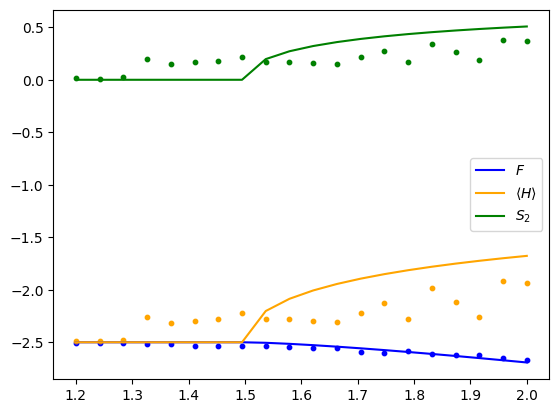

In [40]:
plt.scatter(T_array, free_energy_results, color="Blue", s=10)
plt.scatter(T_array, energy_results, color="Orange", s=10)
plt.scatter(T_array, entropy_results, color="Green", s=10)
plt.plot(T_array, free_energy_results_scipy, label=r"$F$", color="Blue")
plt.plot(T_array, energy_results_scipy, label=r"$\langle H\rangle$", color="Orange")
plt.plot(T_array, entropy_results_scipy, label=r"$S_2$", color="Green")
plt.legend()
plt.show()

In [37]:
#Avisar de que ha acabado
import requests
import os
from datetime import datetime
from dotenv import load_dotenv
load_dotenv()

def enviar_grafica_telegram():

    bot_token = os.getenv("TELEGRAM_TOKEN")
    chat_id = os.getenv("TELEGRAM_ID")

    archivo = "output.png"

    if not os.path.exists(archivo):
        requests.post(
            f"https://api.telegram.org/bot{bot_token}/sendMessage",
            json={"chat_id": chat_id, "text": f"❌ No existe {archivo}"}
        )
        return False

    with open(archivo, "rb") as f:
        files = {"photo": f}

        caption = (
            "✅ Notebook completado\n"
            f"📅 {datetime.now():%Y-%m-%d %H:%M:%S}\n"
            f"📁 {os.path.getsize(archivo)/1024:.1f} KB"
        )

        response = requests.post(
            f"https://api.telegram.org/bot{bot_token}/sendPhoto",
            data={"chat_id": chat_id, "caption": caption},
            files=files
        )

    if not response.ok:
        print("Error Telegram:", response.text)

    return response.ok

